In [ ]:
import os
import tarfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, accuracy_score, f1_score
from google.colab import drive
import math

# --- 1. CONNECT TO DRIVE PERMANENTLY ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 2. FAST SETUP FUNCTION ---
def setup_data():
    # Define paths inside the function to avoid errors
    project_folder = '/content/drive/MyDrive/FER_Project'
    drive_file_gz = os.path.join(project_folder, 'fer2013.tar.gz')
    drive_file_tar = os.path.join(project_folder, 'fer2013.tar')

    # 1. Identify which file you have (tar.gz or .tar)
    if os.path.exists(drive_file_gz):
        source_path = drive_file_gz
        mode = 'r:gz'
    elif os.path.exists(drive_file_tar):
        source_path = drive_file_tar
        mode = 'r'
    else:
        # If neither exists, stop and warn
        raise FileNotFoundError(f"⚠️ STOP! I cannot find 'fer2013.tar.gz' inside your Drive folder: {project_folder}")

    # 2. Copy to Colab (Local) for faster training
    local_file = '/content/fer2013_temp.tar.gz'

    # Only copy/extract if we haven't done it yet
    if not os.path.exists('fer2013.csv') and not os.path.exists('fer2013/fer2013.csv'):
        print(f"✅ Found dataset: {source_path}")
        print("Copying to Colab for speed (this takes a few seconds)...")
        shutil.copy(source_path, local_file)

        print("Extracting...")
        with tarfile.open(local_file, mode) as tar:
            tar.extractall()
        print("✅ Extraction Complete!")

    # 3. Load CSV
    csv_path = 'fer2013.csv'
    if not os.path.exists(csv_path) and os.path.exists('fer2013/fer2013.csv'):
        csv_path = 'fer2013/fer2013.csv'

    return pd.read_csv(csv_path)

# Run the Setup
print("TensorFlow Version:", tf.__version__)
data = setup_data()

# --- 3. PREPARE IMAGES ---
pixels = data['pixels'].tolist()
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')]
    face = np.asarray(face).reshape(48, 48)
    faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces = np.expand_dims(faces, -1)
faces /= 255.0

emotions = pd.get_dummies(data['emotion']).values

# Split Data
X_train = faces[data['Usage'] == 'Training']
y_train = emotions[data['Usage'] == 'Training']
X_val = faces[data['Usage'] == 'PublicTest']
y_val = emotions[data['Usage'] == 'PublicTest']
X_test = faces[data['Usage'] == 'PrivateTest']
y_test = emotions[data['Usage'] == 'PrivateTest']

print(f"✅ Data Loaded! Train shape: {X_train.shape}")

# Configuration
BATCH_SIZE = 64
EPOCHS = 65
NUM_CLASSES = 7

# Data Augmentation
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

TensorFlow Version: 2.19.0
✅ Found dataset: /content/drive/MyDrive/FER_Project/fer2013.tar.gz
Copying to Colab for speed (this takes a few seconds)...
Extracting...


/tmp/ipython-input-4245186221.py:47: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


✅ Extraction Complete!
✅ Data Loaded! Train shape: (28709, 48, 48, 1)


In [ ]:
# --- Define Model Architecture ---
def build_proposed_model_1():
    model = models.Sequential()
    # Block 1
    model.add(layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal', input_shape=(48, 48, 1)))
    model.add(layers.ELU()); model.add(layers.BatchNormalization()); model.add(layers.MaxPooling2D((2, 2))); model.add(layers.Dropout(0.25))
    # Block 2
    model.add(layers.Conv2D(128, (5, 5), padding='same', kernel_initializer='he_normal'))
    model.add(layers.ELU()); model.add(layers.BatchNormalization()); model.add(layers.MaxPooling2D((2, 2))); model.add(layers.Dropout(0.25))
    # Block 3
    model.add(layers.Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal'))
    model.add(layers.ELU()); model.add(layers.BatchNormalization()); model.add(layers.MaxPooling2D((2, 2))); model.add(layers.Dropout(0.25))
    # Block 4
    model.add(layers.Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal'))
    model.add(layers.ELU()); model.add(layers.BatchNormalization()); model.add(layers.MaxPooling2D((2, 2))); model.add(layers.Dropout(0.25))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, kernel_initializer='he_normal'))
    model.add(layers.ELU()); model.add(layers.BatchNormalization()); model.add(layers.Dropout(0.5))
    model.add(layers.Dense(512, kernel_initializer='he_normal'))
    model.add(layers.ELU()); model.add(layers.BatchNormalization()); model.add(layers.Dropout(0.5))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

print("\n--- Training Baseline (Paper) ---")
model_base = build_proposed_model_1()
model_base.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                   loss='categorical_crossentropy', metrics=['accuracy'])

# Permanent Save Path
path_base = '/content/drive/MyDrive/FER_Project/baseline_model.keras'

callbacks_base = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(path_base, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

hist_base = model_base.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks_base,
    verbose=1
)


--- Training Baseline (Paper) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/65


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1812 - loss: 2.6620
Epoch 1: val_accuracy improved from -inf to 0.25327, saving model to /content/drive/MyDrive/FER_Project/baseline_model.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 52s 79ms/step - accuracy: 0.1812 - loss: 2.6615 - val_accuracy: 0.2533 - val_loss: 1.8249 - learning_rate: 5.0000e-04
Epoch 2/65
  1/448 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.1875 - loss: 2.1751

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.25327
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1875 - loss: 2.1751 - val_accuracy: 0.2471 - val_loss: 1.8242 - learning_rate: 5.0000e-04
Epoch 3/65
447/448 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2127 - loss: 2.0678
Epoch 3: val_accuracy improved from 0.25327 to 0.25968, saving model to /content/drive/MyDrive/FER_Project/baseline_model.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.2127 - loss: 2.0676 - val_accuracy: 0.2597 - val_loss: 1.7842 - learning_rate: 5.0000e-04
Epoch 4/65
  1/448 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.2656 - loss: 1.9815
Epoch 4: val_accuracy improved from 0.25968 to 0.26024, saving model to /content/drive/MyDrive/FER_Project/baseline_model.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2656 - loss: 1.9815 - val_accuracy: 0.2602 - val_loss: 1.7868 - learning_rate: 5.0000e-04
Epoch 5/65
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2336 - loss: 

In [ ]:
import tensorflow as tf
import math

# --- Define Cosine Decay with Warmup Schedule (FIXED FOR SAVING) ---
class WarmUpCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, start_lr, target_lr, warmup_steps, total_steps):
        super().__init__()
        self.start_lr = start_lr
        self.target_lr = target_lr
        # Save raw numbers for config (Fixes the saving error!)
        self.warmup_steps_raw = warmup_steps
        self.total_steps_raw = total_steps

        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.total_steps = tf.cast(total_steps, tf.float32)
        self.pi = tf.constant(math.pi)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.start_lr + (self.target_lr - self.start_lr) * (step / self.warmup_steps)
        progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        cosine_lr = 0.5 * self.target_lr * (1 + tf.cos(self.pi * progress))
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        # Return the raw python numbers, not Tensors
        return {
            "start_lr": self.start_lr,
            "target_lr": self.target_lr,
            "warmup_steps": self.warmup_steps_raw,
            "total_steps": self.total_steps_raw,
        }

print("\n--- Training Extended (AdamW) ---")
model_ext = build_proposed_model_1()

# Config
total_steps = (len(X_train) // BATCH_SIZE) * EPOCHS
warmup_steps = int(0.1 * total_steps)
lr_schedule = WarmUpCosineDecay(start_lr=1e-6, target_lr=0.001, warmup_steps=warmup_steps, total_steps=total_steps)

model_ext.compile(optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])

# Permanent Save Path
path_ext = '/content/drive/MyDrive/FER_Project/extended_model.keras'

callbacks_ext = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(path_ext, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

hist_ext = model_ext.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks_ext,
    verbose=1
)


--- Training Extended (AdamW) ---
Epoch 1/65
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1507 - loss: 3.0796
Epoch 1: val_accuracy improved from -inf to 0.27724, saving model to /content/drive/MyDrive/FER_Project/extended_model.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.1508 - loss: 3.0793 - val_accuracy: 0.2772 - val_loss: 1.9354
Epoch 2/65
  1/448 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.1562 - loss: 2.8735
Epoch 2: val_accuracy improved from 0.27724 to 0.27863, saving model to /content/drive/MyDrive/FER_Project/extended_model.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1562 - loss: 2.8735 - val_accuracy: 0.2786 - val_loss: 1.9303
Epoch 3/65
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1849 - loss: 2.5436
Epoch 3: val_accuracy did not improve from 0.27863
448/448 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.1849 - loss: 2.5434 - val_accuracy: 0.2664 - val_loss: 1.8323
Epoch 4/65
  1/448 ━━━━━━━━━━━━━━━━━━━━ 12s 

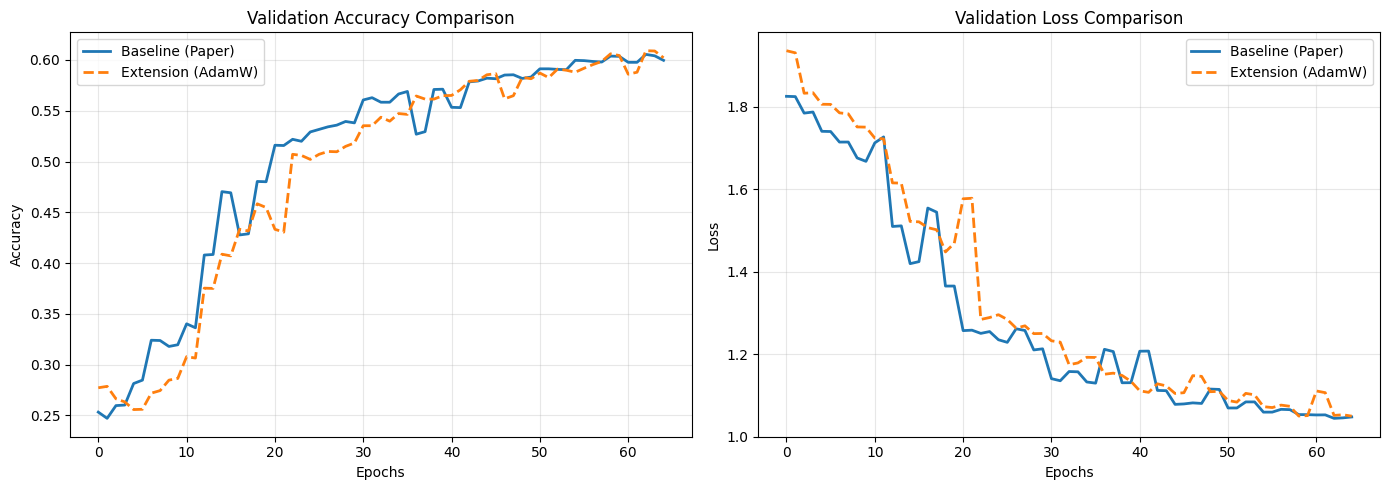


Final Comparison on Private Test Set:

--- Results for Baseline ---
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Accuracy: 0.6261
Weighted F1 Score: 0.6103

Classification Report:
              precision    recall  f1-score   support

       Angry       0.54      0.58      0.56       491
     Disgust       0.73      0.15      0.24        55
        Fear       0.55      0.29      0.38       528
       Happy       0.81      0.89      0.85       879
         Sad       0.49      0.40      0.44       594
    Surprise       0.73      0.74      0.74       416
     Neutral       0.53      0.74      0.62       626

    accuracy                           0.63      3589
   macro avg       0.62      0.54      0.55      3589
weighted avg       0.62      0.63      0.61      3589


--- Results for Extended ---
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Accuracy: 0.6099
Weighted F1 Score: 0.5934

Classification Report:
              precision    recall  f1-score   support

       Angry       0.49      0.

In [ ]:
# --- Helper to plot and print results ---
def evaluate_and_print(model, name, X, y):
    print(f"\n--- Results for {name} ---")
    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1 Score: {f1:.4f}")

    emotions = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=emotions))
    return acc

# 1. Plot Training History
# We use the 'history' variables that are already in memory
if 'hist_base' in locals() and 'hist_ext' in locals():
    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(hist_base.history['val_accuracy'], label='Baseline (Paper)', linewidth=2)
    plt.plot(hist_ext.history['val_accuracy'], label='Extension (AdamW)', linestyle='--', linewidth=2)
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(hist_base.history['val_loss'], label='Baseline (Paper)', linewidth=2)
    plt.plot(hist_ext.history['val_loss'], label='Extension (AdamW)', linestyle='--', linewidth=2)
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not find training history in memory (did you restart?). Skipping plots.")

# 2. Final Evaluation on Private Test Set
print("\nFinal Comparison on Private Test Set:")

# DIRECTLY USE THE MODELS FROM MEMORY
# We skip the 'load_model' lines because they are causing the error.
# The models 'model_base' and 'model_ext' are still alive from the previous cells.

if 'model_base' in locals() and 'model_ext' in locals():
    evaluate_and_print(model_base, "Baseline", X_test, y_test)
    evaluate_and_print(model_ext, "Extended", X_test, y_test)
else:
    print("⚠️ Error: Models not found in memory. If you restarted the runtime, you must re-run Section 2 and 3.")